# Probability Calibration — Illustrated

A model's `predict_proba` is **not** automatically a probability.
A *well-calibrated* classifier outputs scores where, of all examples scored at $p$, the true positive rate really is $p$.

Models that are typically well-calibrated: **logistic regression, naive Bayes (sometimes)**.
Models that need calibration: **SVMs, random forests, gradient boosting, neural nets without softmax temperature**.


## The picture — reliability diagram: predicted vs observed positive rate

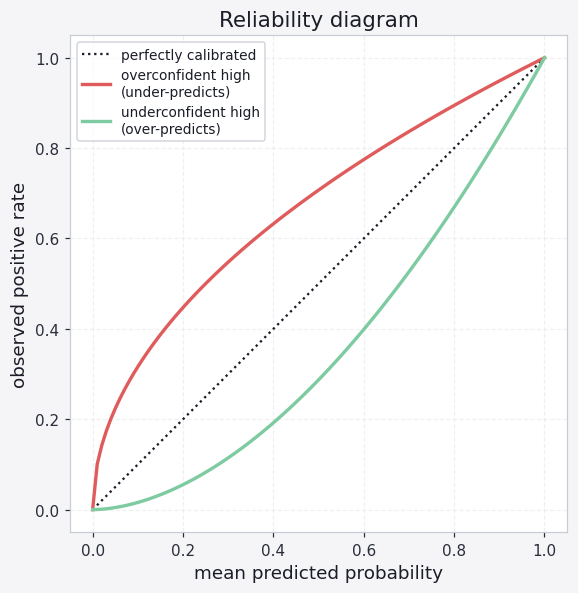

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
p = np.linspace(0, 1, 100)
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(p, p, color='#1a1d27', ls=':', lw=1.5, label='perfectly calibrated')
ax.plot(p, p**0.5, color=P[1], lw=2.2, label='overconfident high\n(under-predicts)')
ax.plot(p, p**1.8, color=P[3], lw=2.2, label='underconfident high\n(over-predicts)')
ax.set_xlabel('mean predicted probability'); ax.set_ylabel('observed positive rate')
ax.set_aspect('equal'); ax.set_title('Reliability diagram')
ax.legend(loc='upper left', fontsize=9); ax.grid(True)
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

X, y = make_classification(n_samples=6000, n_features=12, n_informative=6,
                           random_state=0, flip_y=0.05)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)


---
## Reliability diagrams — uncalibrated

For each model, bin predictions by score and compare *predicted* vs *actual* positive rate.


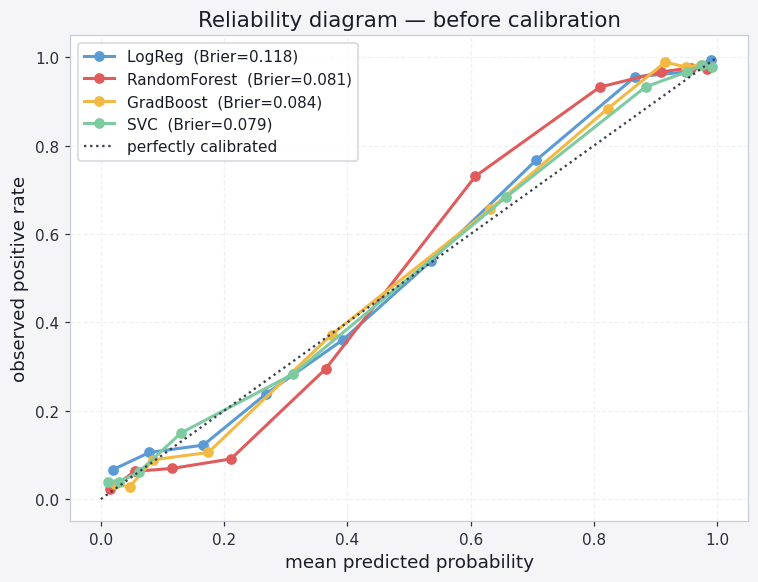

In [3]:
models = {
    'LogReg':     LogisticRegression(max_iter=2000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=0),
    'GradBoost':  GradientBoostingClassifier(random_state=0),
    'SVC':        SVC(probability=True, random_state=0),
}
proba = {}
brier = {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    proba[name] = p
    brier[name] = brier_score_loss(yte, p)

fig, ax = plt.subplots(figsize=(7, 5.4))
for (name, p), c in zip(proba.items(), PALETTE):
    frac, mean = calibration_curve(yte, p, n_bins=10, strategy='quantile')
    ax.plot(mean, frac, marker='o', color=c, lw=2,
            label=f'{name}  (Brier={brier[name]:.3f})')
ax.plot([0,1],[0,1], color='#3a3e4a', ls=':', label='perfectly calibrated')
ax.set_xlabel('mean predicted probability')
ax.set_ylabel('observed positive rate')
ax.set_title('Reliability diagram — before calibration')
ax.legend(loc='upper left'); ax.grid(True)
plt.tight_layout(); plt.show()


---
## Platt vs isotonic calibration

Wrap the worst-calibrated model in `CalibratedClassifierCV`.


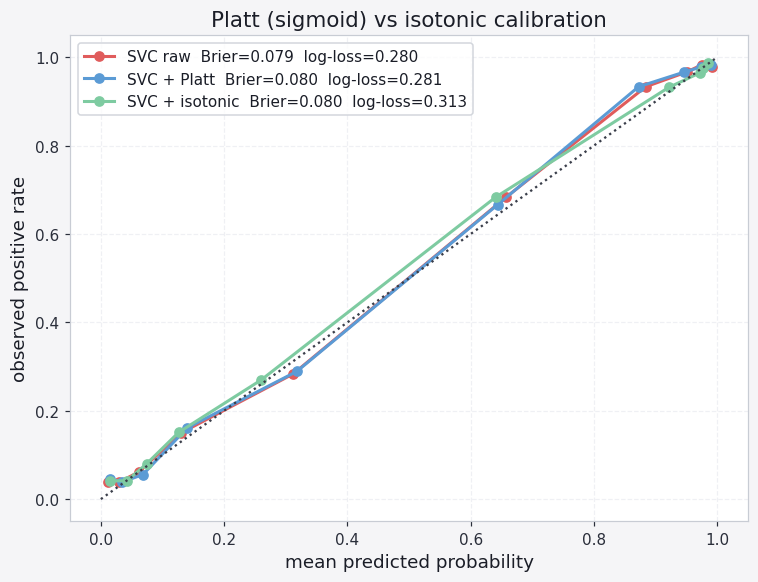

In [4]:
base = SVC(probability=True, random_state=0)
sigmoid = CalibratedClassifierCV(base, method='sigmoid', cv=5).fit(Xtr, ytr)
isotonic = CalibratedClassifierCV(SVC(probability=True, random_state=0),
                                   method='isotonic', cv=5).fit(Xtr, ytr)

p_raw = SVC(probability=True, random_state=0).fit(Xtr, ytr).predict_proba(Xte)[:,1]
p_sig = sigmoid.predict_proba(Xte)[:,1]
p_iso = isotonic.predict_proba(Xte)[:,1]

fig, ax = plt.subplots(figsize=(7, 5.4))
for label, p, c in [('SVC raw',      p_raw, PALETTE[1]),
                    ('SVC + Platt',  p_sig, PALETTE[0]),
                    ('SVC + isotonic', p_iso, PALETTE[3])]:
    frac, mean = calibration_curve(yte, p, n_bins=10, strategy='quantile')
    ax.plot(mean, frac, marker='o', color=c, lw=2,
            label=f'{label}  Brier={brier_score_loss(yte, p):.3f}  '
                  f'log-loss={log_loss(yte, p):.3f}')
ax.plot([0,1],[0,1], color='#3a3e4a', ls=':')
ax.set_xlabel('mean predicted probability')
ax.set_ylabel('observed positive rate')
ax.set_title('Platt (sigmoid) vs isotonic calibration')
ax.legend(loc='upper left'); ax.grid(True)
plt.tight_layout(); plt.show()


---
## Score histograms — what the calibration is doing

Calibration reshapes the **distribution of scores**, not just the labels.


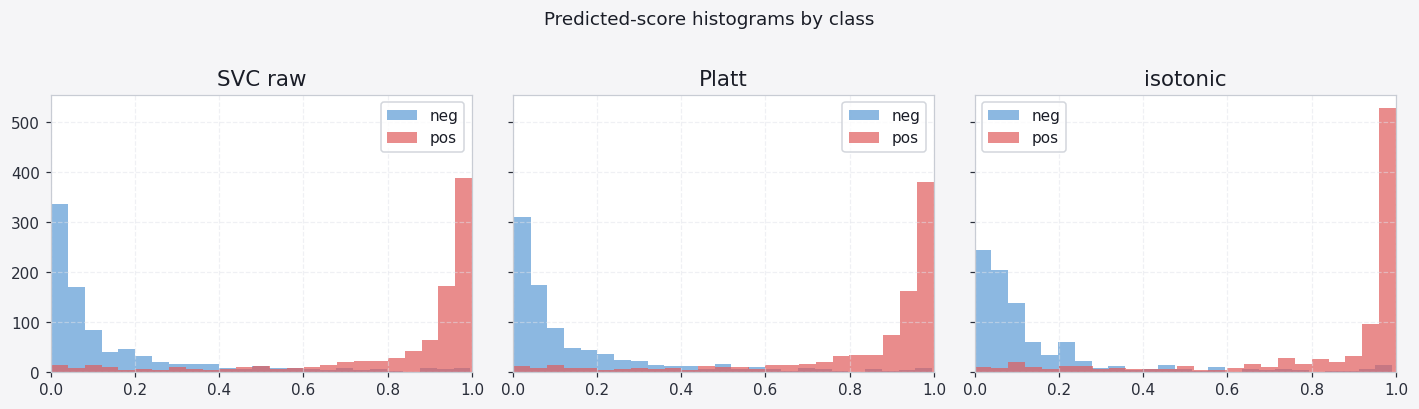

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, p, title in zip(axes, [p_raw, p_sig, p_iso],
                        ['SVC raw', 'Platt', 'isotonic']):
    ax.hist(p[yte==0], bins=25, alpha=0.7, color=PALETTE[0], label='neg')
    ax.hist(p[yte==1], bins=25, alpha=0.7, color=PALETTE[1], label='pos')
    ax.set_title(title); ax.set_xlim(0, 1); ax.grid(True); ax.legend()
fig.suptitle('Predicted-score histograms by class', y=1.02)
plt.tight_layout(); plt.show()


---
## When to use what

- **Platt scaling** (sigmoid) — small validation sets, monotonic miscalibration. 1 parameter pair.
- **Isotonic regression** — larger validation sets (≥1k pos), fixes non-monotonic miscalibration but can overfit small data.
- **Always** evaluate with **Brier score** or **log-loss**, not accuracy. Accuracy is invariant to calibration.

> Where this matters: any decision involving expected value (insurance pricing, ad bidding, medical risk). A miscalibrated model that *ranks* well still produces wrong expectations.
